<a href="https://colab.research.google.com/github/cermegno/langgraph-learning/blob/main/graph3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph 3
Practising conditional edges

In [1]:
!pip install langgraph --quiet

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

User provides "name" and favourite "color" [black or white] on invocation

In [3]:
class State(TypedDict):
  name: str
  color: str
  result: str

In [26]:
def greeting(state: State) -> State:
  """Create a greeting with the user's name"""
  state['result'] = f"Hello {state['name']}"
  print("#1 - Greeting: ", state)
  return state

def color_picker_function(state: State) -> str:   #Literal["white", "black"]
  """Choose a branch depending on the input color"""
  print("#2 - Color Picker: ", state)
  if state['color'] == "white":
    print("     Detected WHITE")
    return "white"
  if state['color'] == "black":
    print("     Detected BLACK")
    return "black"

def white(state: State) -> State:
  """Add white color preference to the result"""
  print("#3 - White: ", state)
  state['result'] += f" your favourite color is {state['color'].upper()}"
  return state

def black(state: State) -> State:
  """Add black color preference to the result"""
  print("#4 - Black: ", state)
  state['result'] += f" your favourite color is {state['color'].upper()}"
  return state

Build the graph

In [27]:
graph = StateGraph(State)
graph.add_node("greet", greeting)
graph.add_node("run_white", white)
graph.add_node("run_black", black)

graph.add_edge(START, "greet")

graph.add_conditional_edges(
    "greet",
    color_picker_function,   # reads state["color"]
    {
        "white": "run_white",
        "black": "run_black"
    },
)

graph.add_edge("run_white", END)
graph.add_edge("run_black", END)
app = graph.compile()

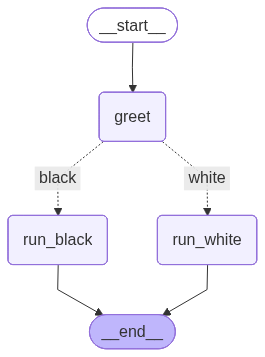

In [28]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

Test it

In [29]:
result = app.invoke({"name": "Tim", "color": "white"})
print(result)

#1 - Greeting:  {'name': 'Tim', 'color': 'white', 'result': 'Hello Tim'}
#2 - Color Picker:  {'name': 'Tim', 'color': 'white', 'result': 'Hello Tim'}
     Detected WHITE
#3 - White:  {'name': 'Tim', 'color': 'white', 'result': 'Hello Tim'}
{'name': 'Tim', 'color': 'white', 'result': 'Hello Tim your favourite color is WHITE'}
